In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [143]:
df = pd.read_csv("/content/cleaned_house_price.csv")

In [144]:
df.head()

,area_type,location,Area,bath,balcony,price,bhk,area_per_bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,2.0,39.07,2,528.0
1,Super built-up Area,Lingadheeranahalli,1521.0,3.0,3.0,95.00,3,507.0
2,Super built-up Area,Whitefield,1170.0,2.0,2.0,38.00,2,585.0
3,Super built-up Area,7th Phase JP Nagar,1000.0,2.0,2.0,38.00,2,500.0
4,Plot Area,Sarjapur,2250.0,3.0,3.0,148.00,3,750.0


In [145]:
df.tail()

,area_type,location,Area,bath,balcony,price,bhk,area_per_bhk
6223,Super built-up Area,Raja Rajeshwari Nagar,1187.0,2.0,2.0,40.14,2,593.500000
6224,Built-up Area,Bannerghatta Road,1527.0,3.0,3.0,142.00,3,509.000000
6225,Super built-up Area,Yeshwanthpur,1675.0,3.0,3.0,92.13,3,558.333333
6226,Super built-up Area,Green Glen Layout,1715.0,3.0,3.0,112.00,3,571.666667
6227,Built-up Area,Raja Rajeshwari Nagar,1141.0,2.0,2.0,60.00,2,570.500000


In [146]:
df.shape

(6228, 8)

In [147]:
df.columns

Index(['area_type', 'location', 'Area', 'bath', 'balcony', 'price', 'bhk',
       'area_per_bhk'],
      dtype='object')

In [148]:
df.isnull().sum()

,0
area_type,0
location,0
Area,0
bath,0
balcony,0
price,0
bhk,0
area_per_bhk,0


In [149]:
df.duplicated().sum()

np.int64(0)

In [150]:
df.drop(columns='area_type',inplace=True)

In [151]:
df.head()

,location,Area,bath,balcony,price,bhk,area_per_bhk
0,Electronic City Phase II,1056.0,2.0,2.0,39.07,2,528.0
1,Lingadheeranahalli,1521.0,3.0,3.0,95.00,3,507.0
2,Whitefield,1170.0,2.0,2.0,38.00,2,585.0
3,7th Phase JP Nagar,1000.0,2.0,2.0,38.00,2,500.0
4,Sarjapur,2250.0,3.0,3.0,148.00,3,750.0


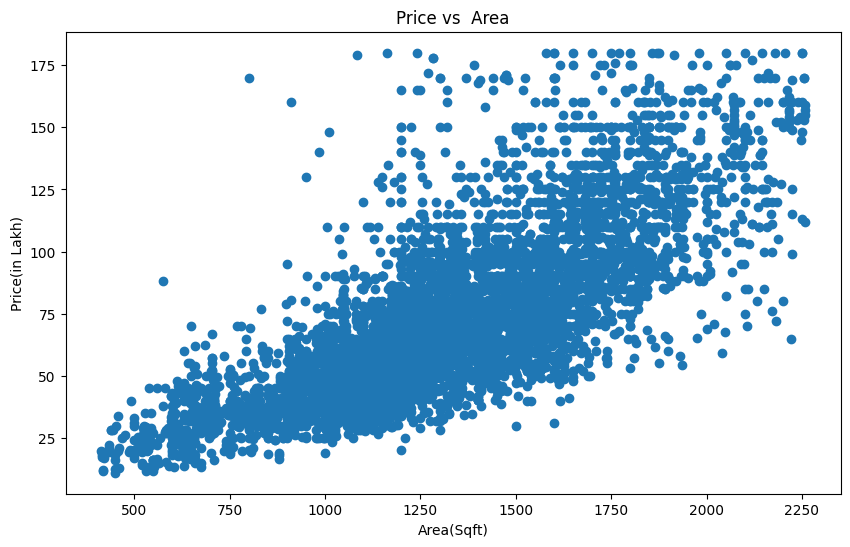

In [152]:
plt.figure(figsize=(10,6))
plt.scatter(df['Area'],df['price'])
plt.title("Price vs  Area")
plt.xlabel("Area(Sqft)")
plt.ylabel("Price(in Lakh)")
plt.show()

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures


In [154]:
x = df[['Area']]
y = df['price']

In [155]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=12)

In [156]:
print("Training Shape:",x_train.shape,y_train.shape)
print("Teesting Shape:",x_test.shape,y_test.shape)

Training Shape: (4982, 1) (4982,)
Teesting Shape: (1246, 1) (1246,)


In [170]:
model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42)
model.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [171]:
print("Training Accuraccy:",model.score(x_train,y_train)*100)

Training Accuraccy: 60.128138543316


In [172]:
print("Testing R² Score:", model.score(x_test, y_test) * 100)

Testing R² Score: 60.82153321447119


In [173]:
y_pred = model.predict(x_test)

In [177]:
print("R2 Score:",r2_score(y_test,y_pred)*100)
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score: 60.82153321447119
MAE: 15.036852372370774
MSE: 435.60553651992063
RMSE: 4.568497038759459


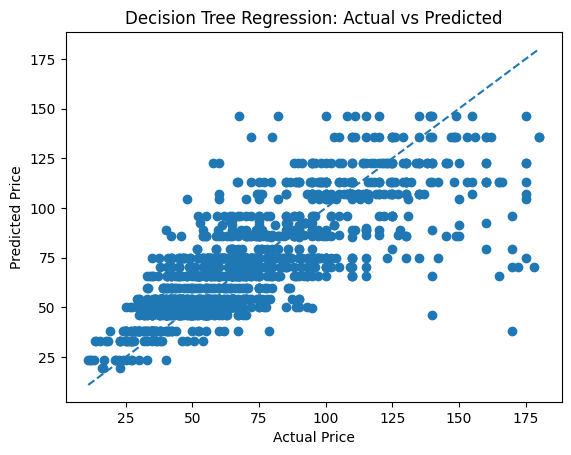

In [175]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree Regression: Actual vs Predicted")

plt.show()